<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%204/week4_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — MLP on MNIST: Activations & Data Prep

**Goal:** Lay the groundwork for a neural network that recognizes handwritten digits. Before building the network itself, we implement the building blocks — activation functions and their derivatives — and prepare the MNIST dataset.


**Today's pieces:**
1. Activation functions (ReLU, sigmoid, tanh) + derivatives, all vectorized
2. Softmax for multi-class output, with the numerical-stability trick
3. Load, visualize, and preprocess MNIST

---

## Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline

---
## 1. Activation Functions & Their Derivatives

Activation functions are the **nonlinearities** placed between layers. Without them, stacking layers would just collapse into a single linear transform, and the network couldn't learn complex patterns. Each one and its derivative:

| Function | Formula | Derivative |
|---|---|---|
| ReLU | $\max(0, x)$ | $1$ if $x>0$, else $0$ |
| Sigmoid | $\dfrac{1}{1+e^{-x}}$ | $\sigma(x)(1-\sigma(x))$ |
| Tanh | $\tanh(x)$ | $1 - \tanh^2(x)$ |

**Everything is vectorized** — these operate on whole NumPy arrays at once, because the network processes batches of images through hundreds of neurons simultaneously. Note `ReLU_deriv` uses `(x > 0).astype(float)` rather than a Python `if`, since `if` can't handle an array of booleans.

In [2]:
def ReLU(x):
  return np.maximum(0, x)

def ReLU_deriv(x):
  return (x > 0).astype(float)

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
  return sigmoid(z) * (1 - sigmoid(z))

def tanh(x):
  return np.tanh(x)

def tanh_deriv(x):
  o = tanh(x)
  return 1 - o**2

---
## 2. Visualize the Activations

Plotting each activation and its derivative directly against the input confirms their shapes match the math:
- **ReLU** — flat at 0 for negatives, then a 45° line; its derivative is a step (0 then 1)
- **Sigmoid** — smooth S-curve from 0 to 1; derivative is a bump peaking at 0.25 at x=0
- **Tanh** — S-curve from −1 to 1; derivative is a bump peaking at 1.0 at x=0

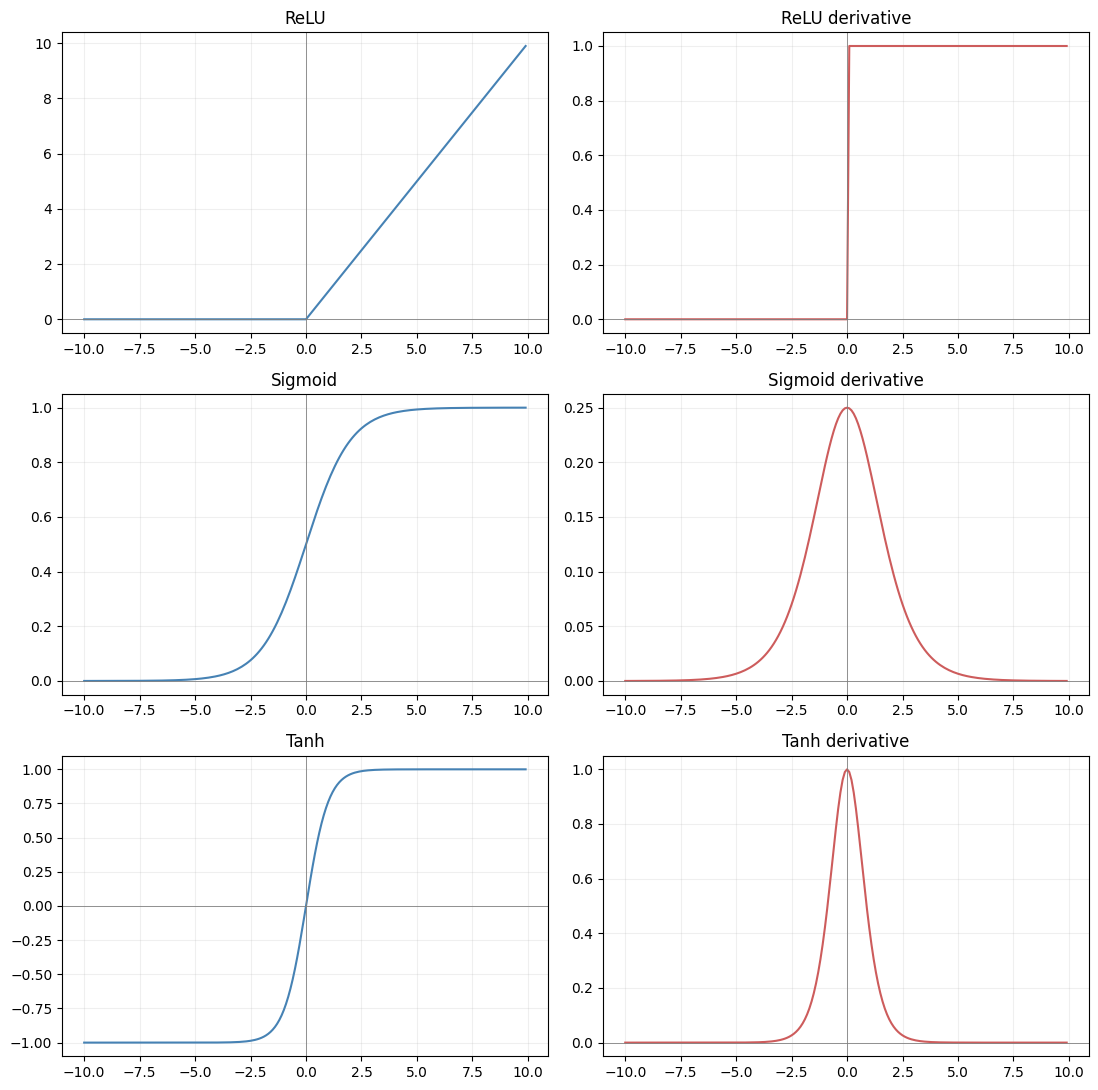

In [3]:
xs = np.arange(-10, 10, 0.1)

fig, axes = plt.subplots(3, 2, figsize=(11, 11))

# ReLU
axes[0,0].plot(xs, ReLU(xs), color='steelblue')
axes[0,0].set_title("ReLU")
axes[0,1].plot(xs, ReLU_deriv(xs), color='indianred')
axes[0,1].set_title("ReLU derivative")

# Sigmoid
axes[1,0].plot(xs, sigmoid(xs), color='steelblue')
axes[1,0].set_title("Sigmoid")
axes[1,1].plot(xs, sigmoid_deriv(xs), color='indianred')
axes[1,1].set_title("Sigmoid derivative")

# Tanh
axes[2,0].plot(xs, tanh(xs), color='steelblue')
axes[2,0].set_title("Tanh")
axes[2,1].plot(xs, tanh_deriv(xs), color='indianred')
axes[2,1].set_title("Tanh derivative")

for ax in axes.flat:
    ax.grid(alpha=0.2)
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.axvline(0, color='gray', linewidth=0.6)

plt.tight_layout()
plt.show()

### What to notice

The **derivative plots explain training behavior**. ReLU's derivative is either 0 or 1 — clean gradients that don't shrink, which is why it's the default for deep networks. Sigmoid's and tanh's derivatives are near-zero far from the origin (the flat tails), so gradients flowing through them in deep networks can shrink toward zero — the **vanishing gradient problem**. Sigmoid's derivative peaks at just 0.25, making this worse than tanh (which peaks at 1.0).

---

## 3. Softmax — Multi-Class Output

MNIST has 10 classes (digits 0–9), so the network's final layer outputs 10 numbers. **Softmax** turns those raw scores (logits) into a probability distribution — values in [0,1] that sum to 1:

$$\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}\$$

### The numerical-stability trick
Raw $e^{z}$ overflows to infinity for large logits. The fix: subtract the max logit from every logit before exponentiating. This leaves the result **mathematically unchanged** (the shift cancels in the ratio) but keeps every exponential ≤ 1, so it never overflows.

### Vectorized for batches
The network feeds softmax a **batch** — a (batch_size × 10) array, one row per image. So `max` and `sum` must operate **per row** using `axis=1`, with `keepdims=True` so the shapes broadcast correctly. Using a global max/sum would incorrectly mix all images together.

In [4]:
def softmax(data):
    # Subtract each row's max for numerical stability (result is unchanged).
    shifted = data - np.max(data, axis=1, keepdims=True)
    e = np.exp(shifted)
    # Normalize each row so it sums to 1.
    return e / np.sum(e, axis=1, keepdims=True)

In [5]:
# Quick check: each row should sum to 1
test_logits = np.array([[2.0, 1.0, 0.1],
                        [1.0, 3.0, 0.2]])
probs = softmax(test_logits)
print(probs)
print("Row sums:", probs.sum(axis=1))   # should both be 1.0

[[0.65900114 0.24243297 0.09856589]
 [0.11314284 0.8360188  0.05083836]]
Row sums: [1. 1.]


---
## 4. Load MNIST

MNIST is 70,000 grayscale images of handwritten digits, each 28×28 pixels flattened into a 784-length vector. We fetch it from OpenML.

In [6]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelBinarizer

mnist = fetch_openml('mnist_784')

X, y = mnist['data'].to_numpy(), mnist['target'].to_numpy()

print("X shape:", X.shape)   # (70000, 784)
print("y shape:", y.shape)   # (70000,)

X shape: (70000, 784)
y shape: (70000,)


### Visualize a few digits

Each 784-vector reshapes back into a 28×28 image.

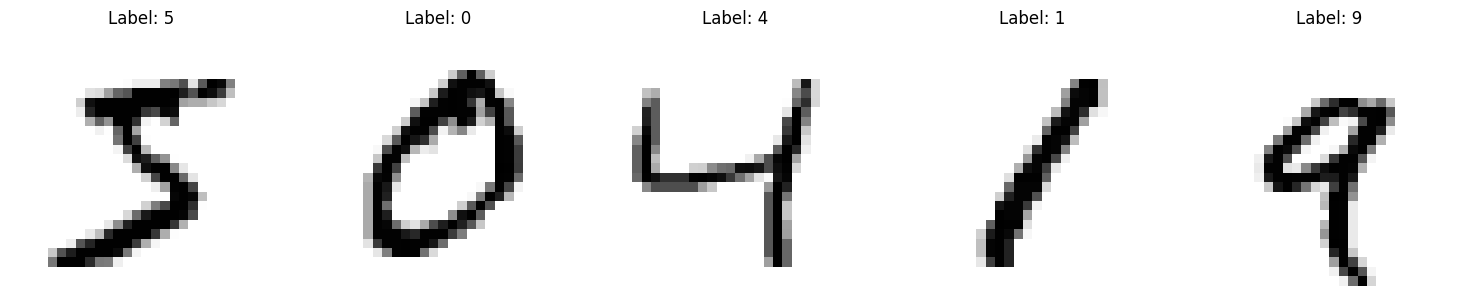

In [7]:
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

for i in range(num_images):
    digit = X[i].reshape(28, 28)        # 784 -> 28x28
    axes[i].imshow(digit, cmap='binary')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Preprocess

Three steps to get the data model-ready:

1. **Scale pixels to [0, 1]** — divide by 255 (the max pixel value). Networks train better when inputs are small and consistent, the same reason we standardized Titanic features.
2. **One-hot encode labels** — turn each digit label into a length-10 vector (e.g. `3` → `[0,0,0,1,0,0,0,0,0,0]`). The 10-way softmax output is compared against this.
3. **Train/test split** — 80% train, 20% test.

In [8]:
# 1. Scale pixels to [0, 1]
X_scaled = X / 255

# 2. One-hot encode the labels into 10 classes
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

print("X_scaled shape:", X_scaled.shape)   # (70000, 784)
print("y_onehot shape:", y_onehot.shape)   # (70000, 10)

X_scaled shape: (70000, 784)
y_onehot shape: (70000, 10)


In [9]:
from sklearn.model_selection import train_test_split

# 3. Split — note we split y_onehot (not the raw string labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=123, shuffle=True
)

In [10]:
print("X_train shape:", X_train.shape)   # (56000, 784)
print("X_test shape: ", X_test.shape)    # (14000, 784)
print("y_train shape:", y_train.shape)   # (56000, 10)
print("y_test shape: ", y_test.shape)    # (14000, 10)

X_train shape: (56000, 784)
X_test shape:  (14000, 784)
y_train shape: (56000, 10)
y_test shape:  (14000, 10)


---
## Summary

| Built today | Detail |
|---|---|
| Activations | ReLU, sigmoid, tanh + derivatives, all vectorized |
| Softmax | Numerically stable, batch-vectorized (axis=1) |
| MNIST loaded | 70,000 images, 784 features each |
| Preprocessed | Pixels scaled to [0,1], labels one-hot, 80/20 split |

The data is now ready: `X_train` (56000 × 784), `y_train` (56000 × 10), and matching test sets.

**Next: build the Dense layer with forward + backward passes, then assemble the full MLP and train it to >97% accuracy on these digits.**